# Extended Syllogistic Logic Dataset (d=16-30)

This notebook demonstrates the **extended synthetic syllogistic logic dataset**, which contains Z3-verified polysyllogism problems with premise counts ranging from 16 to 30 (even steps).

**Key properties:**
- 8 difficulty levels (d=16, 18, 20, 22, 24, 26, 28, 30)
- 4 chain templates (A/B/C/D) with different quantifier patterns
- Balanced TRUE/FALSE answers per difficulty level
- Shuffled premise order requiring chain reconstruction
- Entity names drawn from 8 semantic categories (119-name pool)
- Problem IDs 280-439 (merge-compatible with original d=2-15 dataset)

We load a curated 32-example subset, analyze its structure, run a heuristic baseline, and visualize difficulty scaling.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed for this demo

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import random
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tabulate import tabulate

## Load Dataset

Load the curated 32-example subset from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/dataset_iter3_extend_syllogis/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} examples from dataset '{data['datasets'][0]['dataset']}'")
print(f"Problem IDs: {min(e['metadata_problem_id'] for e in examples)}-{max(e['metadata_problem_id'] for e in examples)}")

Loaded 32 examples from dataset 'syllogistic_logic'
Problem IDs: 280-437


## Configuration

Parameters controlling the analysis scope. The full dataset uses d=16-30 (even), 20 problems per level, 4 templates (A/B/C/D).

In [5]:
# -- Analysis Configuration --
# Number of example problems to display in detail
N_DISPLAY_EXAMPLES = 2
# Difficulty levels in the full dataset (d=16,18,...,30)
DIFFICULTY_RANGE = [16, 18, 20, 22, 24, 26, 28, 30]
# Templates used in the dataset
TEMPLATES = ["A", "B", "C", "D"]
# Seed for reproducible sampling in analysis
SEED = 4242
# Maximum number of examples for heuristic evaluation (use all loaded)
MAX_EVAL_EXAMPLES = len(examples)

## Inspect Example Problems

Each problem presents a set of shuffled syllogistic premises and asks whether a conclusion follows. The difficulty is parameterized by the number of premises (chain depth).

In [6]:
# Show a few example problems at different difficulty levels
shown = 0
for ex in examples:
    if shown >= N_DISPLAY_EXAMPLES:
        break
    print(f"=== Problem {ex['metadata_problem_id']} (d={ex['metadata_difficulty']}, "
          f"template={ex['metadata_template']}, answer={ex['output']}) ===")
    print(ex["input"][:500])
    if len(ex["input"]) > 500:
        print(f"  ... [{len(ex['input'])} chars total]")
    print(f"\nExpected answer: {ex['output']}")
    print(f"Chain: {' -> '.join(ex['metadata_chain_order'][:5])} -> ... -> {ex['metadata_chain_order'][-1]}")
    print(f"Quantifier pattern: {ex['metadata_quantifier_pattern'][:40]}...")
    print()
    shown += 1

=== Problem 280 (d=16, template=A, answer=TRUE) ===
Consider the following statements:
1. All Koreans are nurses.
2. All penguins are virtuosos.
3. All fruits are reefs.
4. Every soldier is an appliance.
5. All glasses are penguins.
6. Every reef is a polymer.
7. All submarines are legumes.
8. Every forest is a glass.
9. All nurses are submarines.
10. Every Norwegian is a soldier.
11. All diamonds are deer.
12. All legumes are forests.
13. Every appliance is a fruit.
14. All mathematicians are Koreans.
15. All deer are mathematicians.
16. Every v
  ... [621 chars total]

Expected answer: TRUE
Chain: diamonds -> deer -> mathematicians -> Koreans -> nurses -> ... -> polymers
Quantifier pattern: All-All-All-All-All-All-All-All-All-All-...

=== Problem 287 (d=16, template=B, answer=FALSE) ===
Consider the following statements:
1. All orators are Canadians.
2. Every turtle is a soldier.
3. Every volcano is a laser.
4. Every Finn is an island.
5. Every writer is a cactus.
6. Every island is 

## Dataset Balance Verification

Verify the distribution of problems across difficulty levels, templates, and TRUE/FALSE labels.

In [7]:
# Build a DataFrame for analysis
df = pd.DataFrame([{
    "problem_id": ex["metadata_problem_id"],
    "difficulty": ex["metadata_difficulty"],
    "template": ex["metadata_template"],
    "answer": ex["output"],
    "conclusion_type": ex["metadata_conclusion_type"],
    "n_entities": len(ex["metadata_entities"]),
    "input_chars": len(ex["input"]),
} for ex in examples[:MAX_EVAL_EXAMPLES]])

# Balance verification table
by_difficulty = df.groupby("difficulty")
rows = []
for d, grp in by_difficulty:
    n_true = (grp["answer"] == "TRUE").sum()
    n_false = (grp["answer"] == "FALSE").sum()
    template_counts = grp["template"].value_counts()
    rows.append([
        d, len(grp), n_true, n_false,
        template_counts.get("A", 0), template_counts.get("B", 0),
        template_counts.get("C", 0), template_counts.get("D", 0),
        grp["input_chars"].max(),
    ])

headers = ["d", "Total", "TRUE", "FALSE", "A", "B", "C", "D", "MaxChars"]
print(tabulate(rows, headers=headers, tablefmt="simple"))
print(f"\nOverall: {len(df)} problems, {(df['answer']=='TRUE').sum()} TRUE / {(df['answer']=='FALSE').sum()} FALSE")

  d    Total    TRUE    FALSE    A    B    C    D    MaxChars
---  -------  ------  -------  ---  ---  ---  ---  ----------
 16        4       2        2    1    1    1    1         621
 18        4       2        2    1    1    1    1         703
 20        4       2        2    1    1    1    1         725
 22        4       2        2    1    1    1    1         792
 24        4       2        2    1    1    1    1         886
 26        4       2        2    1    1    1    1         926
 28        4       2        2    1    1    1    1         973
 30        4       2        2    1    1    1    1        1036

Overall: 32 problems, 16 TRUE / 16 FALSE


## Heuristic Baseline

A simple keyword-based heuristic from the original script: if the query mentions "all"/"every" and any premise mentions "no", predict FALSE; otherwise predict TRUE. This tests whether the problems can be trivially solved without chain reasoning.

In [8]:
def heuristic_baseline(problem: dict) -> str:
    """Simple keyword heuristic: if query says 'All' and any premise says 'No', answer FALSE."""
    input_text = problem["input"]
    lines = input_text.split("\n")

    # Extract query line
    query_line = ""
    for line in lines:
        if "Based on the above" in line:
            query_line = line
            break

    # Check if query mentions 'all'
    query_mentions_all = "all " in query_line.lower() or "every " in query_line.lower()

    # Check if any premise mentions 'no'
    premise_mentions_no = False
    for line in lines:
        if line.strip() and line[0].isdigit():
            if line.lower().startswith(f"{line.split('.')[0]}.") and ("no " in line.lower().split(". ", 1)[-1][:5]):
                premise_mentions_no = True
                break

    if query_mentions_all and premise_mentions_no:
        return "FALSE"
    return "TRUE"


def count_chain_reconstruction_steps(d: int) -> int:
    """Estimate entity-matching steps to reconstruct chain from shuffled premises."""
    return d * (d - 1) // 2


# Evaluate heuristic on all examples
eval_examples = examples[:MAX_EVAL_EXAMPLES]
heuristic_results = []
for ex in eval_examples:
    pred = heuristic_baseline(ex)
    correct = pred == ex["output"]
    heuristic_results.append({
        "problem_id": ex["metadata_problem_id"],
        "difficulty": ex["metadata_difficulty"],
        "template": ex["metadata_template"],
        "answer": ex["output"],
        "prediction": pred,
        "correct": correct,
    })

heur_df = pd.DataFrame(heuristic_results)

# Per-difficulty accuracy
heur_by_d = heur_df.groupby("difficulty")["correct"].mean()
print("Heuristic baseline accuracy by difficulty:")
for d, acc in heur_by_d.items():
    steps = count_chain_reconstruction_steps(d)
    print(f"  d={d:>2}: {acc:>6.1%}  (~{steps} chain reconstruction steps)")
print(f"\nOverall: {heur_df['correct'].mean():.1%}")

Heuristic baseline accuracy by difficulty:
  d=16:  75.0%  (~120 chain reconstruction steps)
  d=18:  75.0%  (~153 chain reconstruction steps)
  d=20:  75.0%  (~190 chain reconstruction steps)
  d=22:  75.0%  (~231 chain reconstruction steps)
  d=24:  75.0%  (~276 chain reconstruction steps)
  d=26:  75.0%  (~325 chain reconstruction steps)
  d=28:  75.0%  (~378 chain reconstruction steps)
  d=30:  75.0%  (~435 chain reconstruction steps)

Overall: 75.0%


## Visualization

Visualize how problem complexity scales with difficulty: input length, chain reconstruction steps, entity count, and heuristic baseline performance.

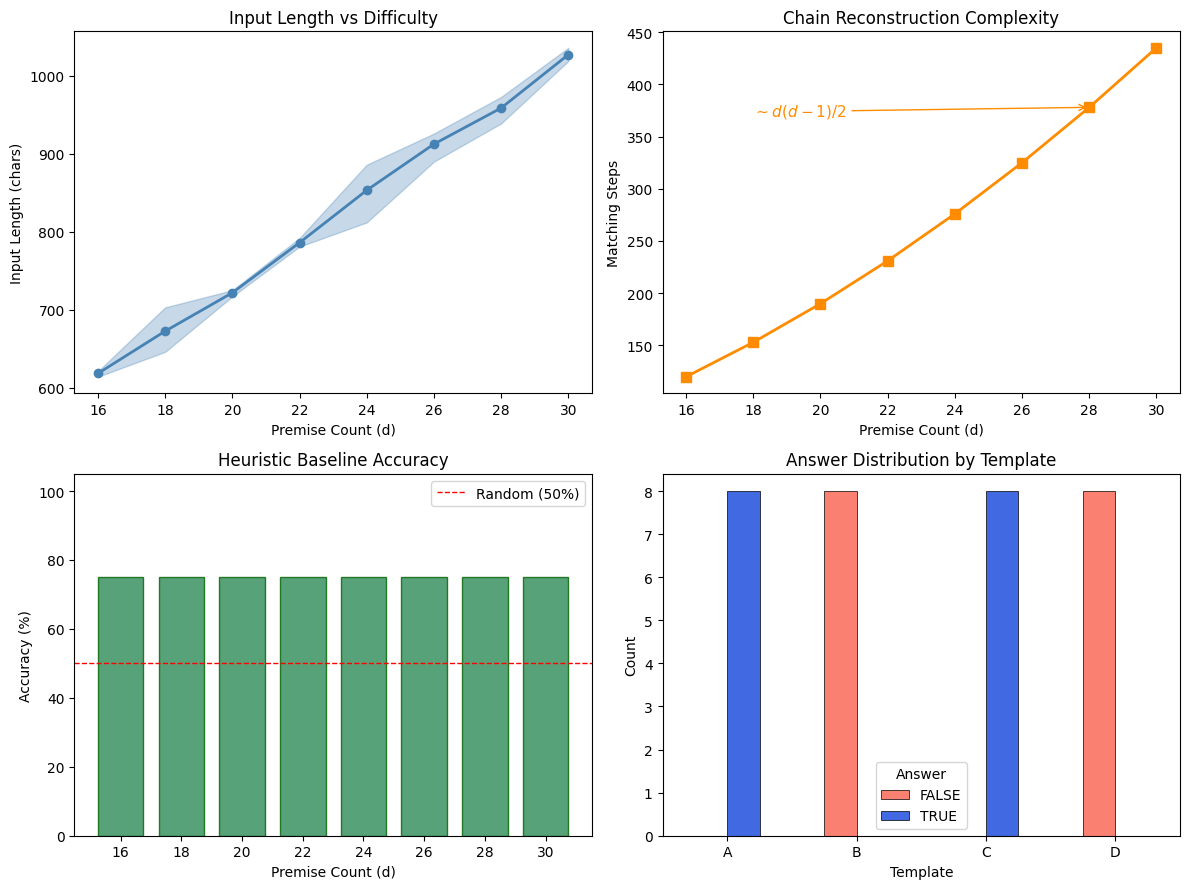

Saved visualization to demo_analysis.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

difficulty_levels = sorted(df["difficulty"].unique())

# --- Panel 1: Input length by difficulty ---
ax = axes[0, 0]
input_stats = df.groupby("difficulty")["input_chars"].agg(["mean", "min", "max"])
ax.fill_between(input_stats.index, input_stats["min"], input_stats["max"], alpha=0.3, color="steelblue")
ax.plot(input_stats.index, input_stats["mean"], "o-", color="steelblue", linewidth=2, markersize=6)
ax.set_xlabel("Premise Count (d)")
ax.set_ylabel("Input Length (chars)")
ax.set_title("Input Length vs Difficulty")
ax.xaxis.set_major_locator(mticker.FixedLocator(difficulty_levels))

# --- Panel 2: Chain reconstruction steps (quadratic) ---
ax = axes[0, 1]
steps = [count_chain_reconstruction_steps(d) for d in difficulty_levels]
ax.plot(difficulty_levels, steps, "s-", color="darkorange", linewidth=2, markersize=7)
ax.set_xlabel("Premise Count (d)")
ax.set_ylabel("Matching Steps")
ax.set_title("Chain Reconstruction Complexity")
ax.xaxis.set_major_locator(mticker.FixedLocator(difficulty_levels))
# Add O(d^2/2) annotation
ax.annotate(r"$\sim d(d-1)/2$", xy=(difficulty_levels[-2], steps[-2]),
            xytext=(difficulty_levels[1], steps[-1]*0.85),
            fontsize=11, fontstyle="italic", color="darkorange",
            arrowprops=dict(arrowstyle="->", color="darkorange"))

# --- Panel 3: Heuristic accuracy by difficulty ---
ax = axes[1, 0]
heur_acc = heur_df.groupby("difficulty")["correct"].mean()
bars = ax.bar(heur_acc.index, heur_acc.values * 100, width=1.5, color="seagreen", alpha=0.8, edgecolor="darkgreen")
ax.axhline(y=50, color="red", linestyle="--", linewidth=1, label="Random (50%)")
ax.set_xlabel("Premise Count (d)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Heuristic Baseline Accuracy")
ax.set_ylim(0, 105)
ax.xaxis.set_major_locator(mticker.FixedLocator(difficulty_levels))
ax.legend(loc="upper right")

# --- Panel 4: Template & answer distribution ---
ax = axes[1, 1]
template_answer = df.groupby(["template", "answer"]).size().unstack(fill_value=0)
colors = {"TRUE": "royalblue", "FALSE": "salmon"}
template_answer.plot(kind="bar", ax=ax, color=[colors.get(c, "gray") for c in template_answer.columns],
                     edgecolor="black", linewidth=0.5)
ax.set_xlabel("Template")
ax.set_ylabel("Count")
ax.set_title("Answer Distribution by Template")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Answer")

plt.tight_layout()
plt.savefig("demo_analysis.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved visualization to demo_analysis.png")